# Image Denoising using Convolutional Autoencoder on MNIST
**Internship Assignment**

## 1. Introduction
Build a denoising autoencoder for MNIST PNG dataset.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Input,Conv2D,MaxPooling2D,UpSampling2D
from tensorflow.keras.models import Model

## 2. Dataset Paths

In [3]:
train_path = r"C:\Users\Dell\Downloads\archive (1)\mnist_png\training"
test_path = r"C:\Users\Dell\Downloads\archive (1)\mnist_png\testing"

## 3. Load Dataset

In [4]:
train_gen=ImageDataGenerator(rescale=1./255).flow_from_directory(
    train_path,target_size=(28,28),color_mode='grayscale',
    class_mode=None,batch_size=60000,shuffle=False)
x_train=next(train_gen)

test_gen=ImageDataGenerator(rescale=1./255).flow_from_directory(
    test_path,target_size=(28,28),color_mode='grayscale',
    class_mode=None,batch_size=10000,shuffle=False)
x_test=next(test_gen)

print(x_train.shape,x_test.shape)

Found 60000 images belonging to 10 classes.
Found 10000 images belonging to 10 classes.
(60000, 28, 28, 1) (10000, 28, 28, 1)


## 4. Visualize Original Images

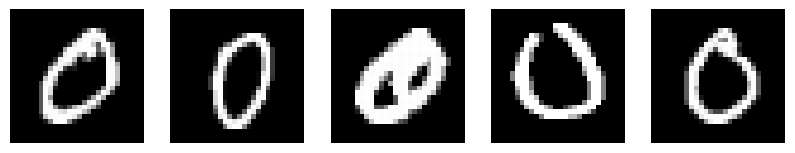

In [5]:
plt.figure(figsize=(10,2))
for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(x_train[i].reshape(28,28),cmap='gray')
    plt.axis('off')
plt.show()

## 5. Add Gaussian Noise

In [6]:
noise_factor=0.5
x_train_noisy=np.clip(x_train+noise_factor*np.random.normal(size=x_train.shape),0.,1.)
x_test_noisy=np.clip(x_test+noise_factor*np.random.normal(size=x_test.shape),0.,1.)

## 6. Build Autoencoder

In [7]:
inp=Input(shape=(28,28,1))
x=Conv2D(32,3,activation='relu',padding='same')(inp)
x=MaxPooling2D(2,padding='same')(x)
x=Conv2D(64,3,activation='relu',padding='same')(x)
enc=MaxPooling2D(2,padding='same')(x)
x=Conv2D(64,3,activation='relu',padding='same')(enc)
x=UpSampling2D(2)(x)
x=Conv2D(32,3,activation='relu',padding='same')(x)
x=UpSampling2D(2)(x)
out=Conv2D(1,3,activation='sigmoid',padding='same')(x)
autoencoder=Model(inp,out)
autoencoder.compile(optimizer='adam',loss='binary_crossentropy')
autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,497 (291.00 KB)

 Trainable params: 74,497 (291.00 KB)

 Non-trainable params: 0 (0.00 B)

## 7. Train Model

In [8]:
history=autoencoder.fit(
    x_train_noisy,x_train,
    epochs=10,
    batch_size=128,
    shuffle=True,
    validation_data=(x_test_noisy,x_test)
)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 58s 110ms/step - loss: 0.1529 - val_loss: 0.1129
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 53s 112ms/step - loss: 0.1099 - val_loss: 0.1053
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 75s 98ms/step - loss: 0.1044 - val_loss: 0.1017
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 45s 97ms/step - loss: 0.1015 - val_loss: 0.0997
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 51s 109ms/step - loss: 0.0996 - val_loss: 0.0980
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 47s 100ms/step - loss: 0.0985 - val_loss: 0.0973
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 44s 93ms/step - loss: 0.0976 - val_loss: 0.0964
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 46s 99ms/step - loss: 0.0969 - val_loss: 0.0965
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 42s 89ms/step - loss: 0.0963 - val_loss: 0.0955
Epoch 10/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 42s 90ms/step - loss: 0.0957 - val_loss: 0.0950


## 8. Predict

In [9]:
decoded=autoencoder.predict(x_test_noisy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step


## 9. Visualize Results

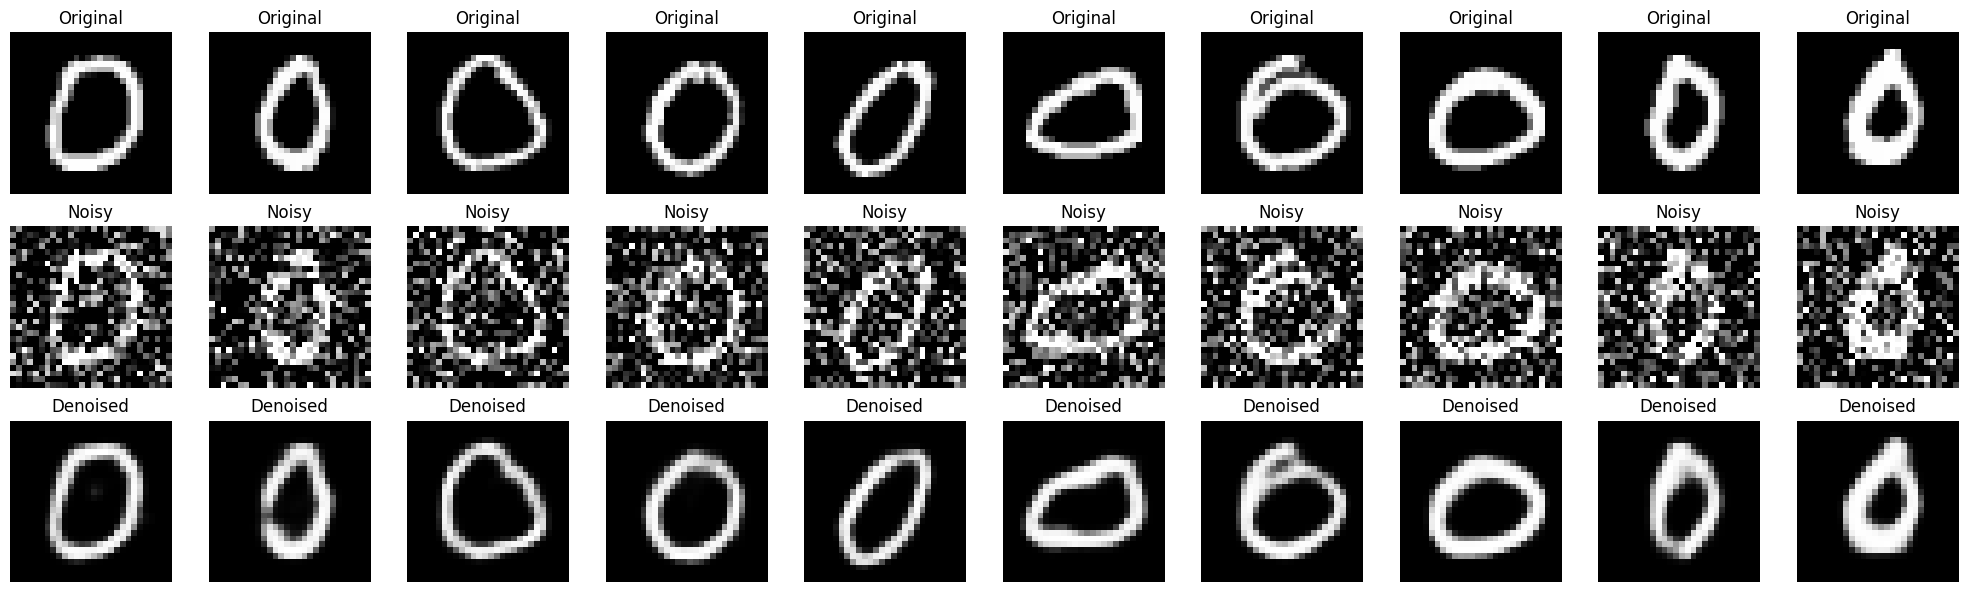

In [10]:
n=10
plt.figure(figsize=(20,6))
for i in range(n):
    plt.subplot(3,n,i+1);plt.imshow(x_test[i].reshape(28,28),cmap='gray');plt.title('Original');plt.axis('off')
    plt.subplot(3,n,i+n+1);plt.imshow(x_test_noisy[i].reshape(28,28),cmap='gray');plt.title('Noisy');plt.axis('off')
    plt.subplot(3,n,i+2*n+1);plt.imshow(decoded[i].reshape(28,28),cmap='gray');plt.title('Denoised');plt.axis('off')
plt.tight_layout();plt.show()

## 10. Training Curve

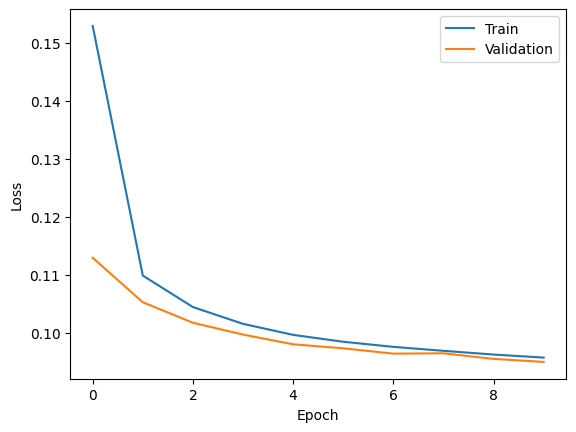

In [11]:
plt.plot(history.history['loss'],label='Train')
plt.plot(history.history['val_loss'],label='Validation')
plt.legend();plt.xlabel('Epoch');plt.ylabel('Loss');plt.show()

## 11. Observations

- Gaussian noise was significantly reduced.
- Digit structure was preserved.
- Validation loss decreased consistently.
- Slight blurring occurs due to latent compression.

## Challenges
- Choosing appropriate noise level.
- Balancing reconstruction quality and model complexity.


## Conclusion
The convolutional denoising autoencoder effectively reconstructs clean handwritten digits from noisy inputs.